Epoch 1 | Train Loss: 0.1287 | Val Loss: 0.0006
Epoch 2 | Train Loss: 0.0004 | Val Loss: 0.0003
Epoch 3 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch 4 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 5 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 6 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 7 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 8 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 9 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 10 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 11 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 12 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 13 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 14 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 15 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 16 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 17 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 18 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 19 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 20 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 21 | Train Loss: 0.0000

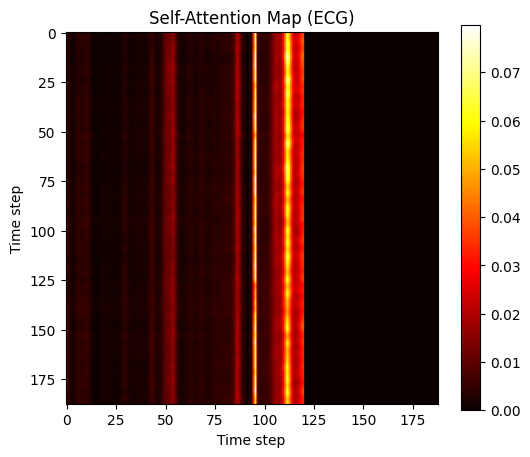

In [ ]:

# -------------------------
# 1. Imports
# -------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# -------------------------
# 2. Load PTBDB CSV files
# -------------------------
normal = pd.read_csv('ptbdb_normal.csv', header=None)
abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)

normal['label'] = 0
abnormal['label'] = 1

data = pd.concat([normal, abnormal], axis=0).reset_index(drop=True)

X = data.iloc[:, :-1].values
y = data['label'].values

# -------------------------
# 3. Train / Val / Test split
# -------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# -------------------------
# 4. Dataset & Dataloader
# -------------------------
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ECGDataset(X_train, y_train)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# -------------------------
# 5. Padding mask
# -------------------------
def create_padding_mask(x):
    return (x != 0)

# -------------------------
# 6. Positional Encoding
# -------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -------------------------
# 7. Encoder with Attention
# -------------------------
class EncoderLayerWithAttention(nn.Module):
    def __init__(self, d_model, nhead):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            d_model, nhead, batch_first=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask):
        attn_out, attn_weights = self.self_attn(
            x, x, x,
            key_padding_mask=~padding_mask,
            need_weights=True
        )
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights

# -------------------------
# 8. ECG Transformer
# -------------------------
class ECGTransformer(nn.Module):
    def __init__(self, seq_len, d_model=64, nhead=4):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        self.positional_encoding = PositionalEncoding(d_model, seq_len)
        self.encoder = EncoderLayerWithAttention(d_model, nhead)
        self.classifier = nn.Linear(d_model, 2)

    def forward(self, x):
        padding_mask = create_padding_mask(x)

        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.positional_encoding(x)

        x, attn_weights = self.encoder(x, padding_mask)

        padding_mask = padding_mask.unsqueeze(-1)
        x = (x * padding_mask).sum(dim=1) / padding_mask.sum(dim=1)

        logits = self.classifier(x)
        return logits, attn_weights

# -------------------------
# 9. Early Stopping
# -------------------------
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict()
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

# -------------------------
# 10. Training
# -------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ECGTransformer(seq_len=X.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=3)

EPOCHS =7

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            val_loss += criterion(logits, yb).item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if early_stopping.step(val_loss, model):
        print("Early stopping triggered")
        break

# restore best model
model.load_state_dict(early_stopping.best_state)

# -------------------------
# 11. Test Evaluation
# -------------------------
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits, _ = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

print(classification_report(all_labels, all_preds))

# -------------------------
# 12. Attention Visualization
# -------------------------
sample, label = test_ds[0]
sample = sample.unsqueeze(0).to(device)

with torch.no_grad():
    _, attn = model(sample)

attn_map = attn[0].cpu().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(attn_map, cmap='hot')
plt.colorbar()
plt.title('Self-Attention Map (ECG)')
plt.xlabel('Time step')
plt.ylabel('Time step')
plt.show()
